# 1 . Opciones vanilla: Monte Carlo GBM vs Black-Scholes cerrado

Este notebook construye calls y puts europeas como `Payoff` -- autoria programatica de AST
(`when`/`cashflow`/`maximum`/`fixing`, `PLAN_PRODUCTS.md SS7`) sobre un modelo `GBM` (medida
riesgo-neutral Q) -- y las valora con la medida Monte Carlo `PayoffPriceQ`. El objetivo es
doble: confirmar que el motor reproduce la teoria clasica (Black-Scholes, paridad put-call,
las Greeks de manual) y, a partir de ahi, mostrar como se construyen y visualizan curvas de
precio/Greeks frente a strike y spot -- el pan de cada dia de un desk de derivados.

Los notebooks siguientes de esta bateria exploran lo que Black-Scholes NO puede dar: barreras
y exoticos (`02`), ejercicio bermuda (`03`), superficies de sensibilidad de segundo orden
(`04`), medida fisica P (`05`) y exposicion/CVA/portfolio (`06`).

**Antes de ejecutar**, compila el proyecto con CMake (ver `PLAN.md` en la raiz del repo) --
el modulo `engine.cp3XX-....pyd`/`engine*.so` debe existir en `build/clients/python`.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, "../../../build/clients/python")
sys.path.insert(0, "../src")

import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import engine
import quantdesk as qd
from quantdesk import greeks

print("modulo engine importado desde:", engine.__file__)


modulo engine importado desde: S:\Projects\engine_quant\clients\python\notebooks\../../../build/clients/python\engine.cp312-win_amd64.pyd


## 1. Mercado y formulas cerradas de Black-Scholes

Reimplementamos Black-Scholes-Merton (con dividendo continuo `q`) en Python puro, solo para
contrastar -- el motor nunca usa esta formula, siempre revalora via simulacion Monte Carlo del
GBM (`PayoffPriceQ`).


In [2]:
import math


def _norm_cdf(x):
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))


def _norm_pdf(x):
    return math.exp(-0.5 * x * x) / math.sqrt(2.0 * math.pi)


def _d1_d2(s0, k, r, q_div, sigma, t):
    d1 = (math.log(s0 / k) + (r - q_div + 0.5 * sigma * sigma) * t) / (sigma * math.sqrt(t))
    d2 = d1 - sigma * math.sqrt(t)
    return d1, d2


def bs_call(s0, k, r, q_div, sigma, t):
    d1, d2 = _d1_d2(s0, k, r, q_div, sigma, t)
    return s0 * math.exp(-q_div * t) * _norm_cdf(d1) - k * math.exp(-r * t) * _norm_cdf(d2)


def bs_put(s0, k, r, q_div, sigma, t):
    d1, d2 = _d1_d2(s0, k, r, q_div, sigma, t)
    return k * math.exp(-r * t) * _norm_cdf(-d2) - s0 * math.exp(-q_div * t) * _norm_cdf(-d1)


def bs_greeks_call(s0, k, r, q_div, sigma, t):
    d1, d2 = _d1_d2(s0, k, r, q_div, sigma, t)
    delta = math.exp(-q_div * t) * _norm_cdf(d1)
    gamma = math.exp(-q_div * t) * _norm_pdf(d1) / (s0 * sigma * math.sqrt(t))
    vega = s0 * math.exp(-q_div * t) * _norm_pdf(d1) * math.sqrt(t)
    theta = (
        -s0 * math.exp(-q_div * t) * _norm_pdf(d1) * sigma / (2.0 * math.sqrt(t))
        - r * k * math.exp(-r * t) * _norm_cdf(d2)
        + q_div * s0 * math.exp(-q_div * t) * _norm_cdf(d1)
    )
    rho = k * t * math.exp(-r * t) * _norm_cdf(d2)
    return {"delta": delta, "gamma": gamma, "vega": vega, "theta": theta, "rho": rho}


S0, R, Q_DIV, SIGMA, T = 100.0, 0.05, 0.015, 0.20, 1.0
OBS = "EQ.SPOT.DEMO"

model = qd.Gbm(s0=S0, r=R, q=Q_DIV, sigma=SIGMA, observable=OBS)
market = qd.Market(pillars=[T], zero_rates=[R])
eng = qd.Engine(backend="cpu", n_paths=500_000, n_steps=1, seed=7)
pricing_sweep = qd.PricingContext(pricing_date=0.0, n_paths=40_000, n_steps=1, seed=7)

print(f"S0={S0}  r={R:.1%}  q={Q_DIV:.1%}  sigma={SIGMA:.1%}  T={T}y")


S0=100.0  r=5.0%  q=1.5%  sigma=20.0%  T=1.0y


## 2. Precio ATM: motor Monte Carlo vs formula cerrada


In [3]:
K_ATM = S0
call = qd.european_call("CALL_ATM", OBS, strike=K_ATM, notional=1.0, maturity=T)
put = qd.european_put("PUT_ATM", OBS, strike=K_ATM, notional=1.0, maturity=T)

mc_call = eng.price(call, model, market, ["PayoffPriceQ"]).PayoffPriceQ.scalar
mc_put = eng.price(put, model, market, ["PayoffPriceQ"]).PayoffPriceQ.scalar
bs_c = bs_call(S0, K_ATM, R, Q_DIV, SIGMA, T)
bs_p = bs_put(S0, K_ATM, R, Q_DIV, SIGMA, T)

print(f"{'':10}{'Monte Carlo':>14}{'Black-Scholes':>16}{'diff':>10}")
print(f"{'Call':10}{mc_call:14.4f}{bs_c:16.4f}{mc_call - bs_c:10.4f}")
print(f"{'Put':10}{mc_put:14.4f}{bs_p:16.4f}{mc_put - bs_p:10.4f}")


             Monte Carlo   Black-Scholes      diff
Call              9.5076          9.5235   -0.0159
Put               6.1573          6.1353    0.0220


## 2bis. Ejemplo con datos reales: volatilidad realizada de AAPL

Los precios anteriores usan una `SIGMA` sintetica (20%). Aqui se descargan datos OHLC diarios
reales de AAPL (`yfinance`, ~1 anio), se dibujan como velas japonesas (`mplfinance`) y se
calcula la volatilidad realizada anualizada a partir de los log-retornos diarios
(`std(log-retornos) * sqrt(252)`). Con ese `sigma` de mercado y el ultimo close como `S0` se
revalora la misma call/put ATM del motor, comparando el precio "real" contra el sintetico de
la seccion anterior.


[*********************100%***********************]  1 of 1 completed

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


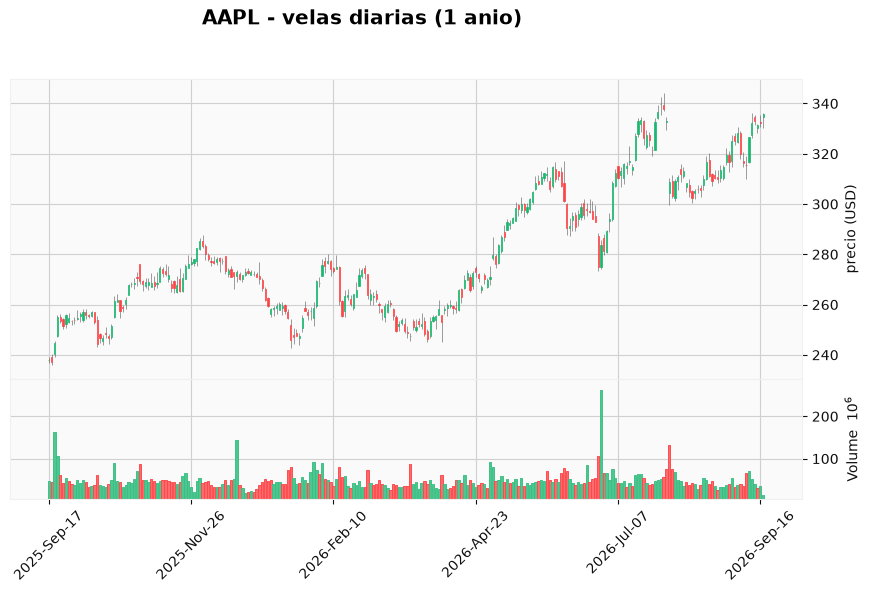

In [4]:
import mplfinance as mpf
import pandas as pd
import yfinance as yf

aapl = yf.download("AAPL", period="1y", auto_adjust=True)
if isinstance(aapl.columns, pd.MultiIndex):
    aapl.columns = aapl.columns.get_level_values(0)

mpf.plot(
    aapl,
    type="candle",
    style="yahoo",
    title="AAPL - velas diarias (1 anio)",
    ylabel="precio (USD)",
    volume=True,
    figsize=(11, 6),
)


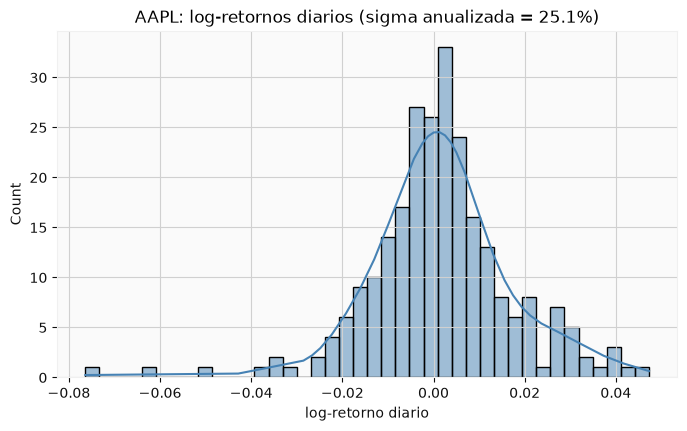

S0 real (ultimo close) = 335.77
sigma realizada anualizada = 25.1%  (sintetica del notebook = 20.0%)


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

log_returns = np.log(aapl["Close"] / aapl["Close"].shift(1)).dropna()
sigma_realized = float(log_returns.std() * np.sqrt(252))
S0_real = float(aapl["Close"].iloc[-1])

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(log_returns, bins=40, kde=True, color="steelblue", ax=ax)
ax.set_title(f"AAPL: log-retornos diarios (sigma anualizada = {sigma_realized:.1%})")
ax.set_xlabel("log-retorno diario")
plt.show()

print(f"S0 real (ultimo close) = {S0_real:.2f}")
print(f"sigma realizada anualizada = {sigma_realized:.1%}  (sintetica del notebook = {SIGMA:.1%})")


In [6]:
model_real = qd.Gbm(s0=S0_real, r=R, q=Q_DIV, sigma=sigma_realized, observable=OBS)
call_real = qd.european_call("CALL_REAL", OBS, strike=S0_real, notional=1.0, maturity=T)
put_real = qd.european_put("PUT_REAL", OBS, strike=S0_real, notional=1.0, maturity=T)

mc_call_real = eng.price(call_real, model_real, market, ["PayoffPriceQ"]).PayoffPriceQ.scalar
mc_put_real = eng.price(put_real, model_real, market, ["PayoffPriceQ"]).PayoffPriceQ.scalar
bs_call_real = bs_call(S0_real, S0_real, R, Q_DIV, sigma_realized, T)
bs_put_real = bs_put(S0_real, S0_real, R, Q_DIV, sigma_realized, T)

print(f"{'':28}{'sintetico (S0=100,sig=20%)':>28}{'real AAPL':>18}")
print(f"{'Call MC':28}{mc_call:28.4f}{mc_call_real:18.4f}")
print(f"{'Put MC':28}{mc_put:28.4f}{mc_put_real:18.4f}")
print(f"{'Call BS':28}{bs_c:28.4f}{bs_call_real:18.4f}")
print(f"{'Put BS':28}{bs_p:28.4f}{bs_put_real:18.4f}")
print(
    "\nLa call/put ATM de AAPL usa un S0 y una sigma de mercado muy distintos de los sinteticos "
    f"(S0 real={S0_real:.2f} vs S0=100, sigma real={sigma_realized:.1%} vs sigma={SIGMA:.1%}), asi "
    "que el valor absoluto en USD no es directamente comparable entre ambos casos -- lo relevante "
    "es que el motor Monte Carlo sigue coincidiendo con Black-Scholes cerrado dentro del ruido "
    "Monte Carlo tambien con parametros de mercado reales, no solo con los sinteticos de la Seccion 2."
)


                              sintetico (S0=100,sig=20%)         real AAPL
Call MC                                           9.5076           38.3909
Put MC                                            6.1573           27.1710
Call BS                                           9.5235           38.4537
Put BS                                            6.1353           27.0769

La call/put ATM de AAPL usa un S0 y una sigma de mercado muy distintos de los sinteticos (S0 real=335.77 vs S0=100, sigma real=25.1% vs sigma=20.0%), asi que el valor absoluto en USD no es directamente comparable entre ambos casos -- lo relevante es que el motor Monte Carlo sigue coincidiendo con Black-Scholes cerrado dentro del ruido Monte Carlo tambien con parametros de mercado reales, no solo con los sinteticos de la Seccion 2.


## 3. Diagrama de payoff a vencimiento


In [7]:
s_grid = np.linspace(0.5 * S0, 1.5 * S0, 200)
payoff_call = np.maximum(s_grid - K_ATM, 0.0)
payoff_put = np.maximum(K_ATM - s_grid, 0.0)

fig = go.Figure()
fig.add_trace(go.Scatter(x=s_grid, y=payoff_call, mode="lines", name="Call", line=dict(width=2)))
fig.add_trace(go.Scatter(x=s_grid, y=payoff_put, mode="lines", name="Put", line=dict(width=2)))
fig.add_vline(x=K_ATM, line=dict(color="grey", dash="dash", width=1), annotation_text=f"strike={K_ATM:.0f}")
fig.update_layout(
    title="Payoff a vencimiento: call vs put europeas ATM",
    xaxis_title="S_T",
    yaxis_title="payoff",
    template="plotly_white",
)
fig.show()


## 4. Curva de precio frente a strike (`price_many`, una sola simulacion por lote)

`price_many` agrupa internamente por calendario y comparte la simulacion Monte Carlo del
tipo corto/spot entre todos los trades del lote -- una sola pasada Monte Carlo basta para
los 13 strikes de cada lado, en vez de 13 llamadas independientes a `Engine.price`.


In [8]:
strikes = np.arange(70.0, 131.0, 5.0)

calls = [qd.european_call(f"CALL_{k:.0f}", OBS, strike=float(k), notional=1.0, maturity=T) for k in strikes]
puts = [qd.european_put(f"PUT_{k:.0f}", OBS, strike=float(k), notional=1.0, maturity=T) for k in strikes]

call_rows = eng.price_many(calls, model, market, ["PayoffPriceQ"])
put_rows = eng.price_many(puts, model, market, ["PayoffPriceQ"])

mc_call_curve = np.array([row.measures.PayoffPriceQ.scalar for row in call_rows])
mc_put_curve = np.array([row.measures.PayoffPriceQ.scalar for row in put_rows])
bs_call_curve = np.array([bs_call(S0, k, R, Q_DIV, SIGMA, T) for k in strikes])
bs_put_curve = np.array([bs_put(S0, k, R, Q_DIV, SIGMA, T) for k in strikes])

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("Precio vs strike: Monte Carlo vs Black-Scholes", "Ruido Monte Carlo (500,000 paths)"),
)
fig.add_trace(go.Scatter(x=strikes, y=bs_call_curve, mode="lines", name="Call BS", line=dict(color="royalblue")), row=1, col=1)
fig.add_trace(
    go.Scatter(x=strikes, y=mc_call_curve, mode="markers", name="Call MC", marker=dict(color="royalblue", symbol="circle-open")),
    row=1,
    col=1,
)
fig.add_trace(go.Scatter(x=strikes, y=bs_put_curve, mode="lines", name="Put BS", line=dict(color="darkorange")), row=1, col=1)
fig.add_trace(
    go.Scatter(x=strikes, y=mc_put_curve, mode="markers", name="Put MC", marker=dict(color="darkorange", symbol="circle-open")),
    row=1,
    col=1,
)
fig.add_vline(x=S0, line=dict(color="grey", dash="dot", width=1), row=1, col=1)

rel_err_call = (mc_call_curve - bs_call_curve) / bs_call_curve * 100.0
rel_err_put = (mc_put_curve - bs_put_curve) / bs_put_curve * 100.0
fig.add_trace(go.Scatter(x=strikes, y=rel_err_call, mode="lines+markers", name="Call err%"), row=1, col=2)
fig.add_trace(go.Scatter(x=strikes, y=rel_err_put, mode="lines+markers", name="Put err%"), row=1, col=2)
fig.add_hline(y=0.0, line=dict(color="grey", width=1), row=1, col=2)

fig.update_xaxes(title_text="strike", row=1, col=1)
fig.update_yaxes(title_text="precio", row=1, col=1)
fig.update_xaxes(title_text="strike", row=1, col=2)
fig.update_yaxes(title_text="error relativo (%)", row=1, col=2)
fig.update_layout(template="plotly_white", width=1100, height=450)
fig.show()


## 5. Paridad put-call como cheque de consistencia


In [9]:
parity_lhs = mc_call_curve - mc_put_curve
parity_rhs = S0 * math.exp(-Q_DIV * T) - strikes * math.exp(-R * T)

fig = go.Figure()
fig.add_trace(go.Scatter(x=strikes, y=parity_rhs, mode="lines", name="S0 e^(-qT) - K e^(-rT)  (teorico)", line=dict(color="black")))
fig.add_trace(
    go.Scatter(x=strikes, y=parity_lhs, mode="markers", name="Call - Put (motor)", marker=dict(color="crimson", symbol="circle-open"))
)
fig.update_layout(
    title="Paridad put-call",
    xaxis_title="strike",
    yaxis_title="Call - Put",
    template="plotly_white",
)
fig.show()

max_abs_diff = float(np.max(np.abs(parity_lhs - parity_rhs)))
print(f"Maxima desviacion de la paridad put-call en la rejilla de strikes: {max_abs_diff:.4f}")


Maxima desviacion de la paridad put-call en la rejilla de strikes: 0.0379


## 6. Greeks de la call ATM: `quantdesk.greeks` vs Black-Scholes

`greeks.theta(...)` (PLAN_GREEKS.md SS7.1, PLAN_IMPROVE_NOTEBOOK.md Fase 4/ADR-IN-01) tiene una
convencion explicita en su propio docstring/API, ya no hay que redescubrirla comparando contra
Black-Scholes:

- `annualized=False` (default): devuelve el DeltaV CRUDO de un unico bump `dt` (un dia por
  defecto, resuelto internamente por el motor) -- `V(t+dt) - V(t)`, sin dividir por `dt`. Es la
  UNICA Greek con esta convencion (delta/gamma/vega/rho si son derivadas propiamente
  normalizadas por el tamano del bump).
- `annualized=True`: devuelve `DeltaV / dt`, la derivada anualizada `dV/dt` -- comparable
  directamente con el theta anualizado de la formula cerrada, sin escalar nada a mano. El
  escalado lo aplica `ThetaGreek.annualize(...)` en Python sobre el `MeasureResult` que ya
  devolvio el motor, leyendo `bump_used` de ahi (PLAN_IMPROVE_NOTEBOOK2.md Fase 5: el bump
  EFECTIVAMENTE usado por el motor, ya no una constante Python duplicada).

Abajo se comparan ambas convenciones contra Black-Scholes en la misma tabla.


In [10]:
delta_mc = eng.price(call, model, market, [greeks.delta("PayoffPriceQ", "spot")]).Greek.scalar
gamma_mc = eng.price(call, model, market, [greeks.gamma("PayoffPriceQ", "spot")]).Greek.scalar
vega_mc = eng.price(call, model, market, [greeks.vega("PayoffPriceQ")]).Greek.scalar
rho_mc = eng.price(call, model, market, [greeks.rho("PayoffPriceQ")]).Greek.scalar

theta_raw_greek = greeks.theta("PayoffPriceQ")
theta_raw_result = eng.price(call, model, market, [theta_raw_greek]).Greek
theta_raw_mc = theta_raw_greek.annualize(theta_raw_result)

theta_annualized_greek = greeks.theta("PayoffPriceQ", annualized=True)
theta_annualized_result = eng.price(call, model, market, [theta_annualized_greek]).Greek
theta_annualized_mc = theta_annualized_greek.annualize(theta_annualized_result)

bs_g = bs_greeks_call(S0, K_ATM, R, Q_DIV, SIGMA, T)
rows = [
    ("delta", delta_mc, bs_g["delta"]),
    ("gamma", gamma_mc, bs_g["gamma"]),
    ("vega", vega_mc, bs_g["vega"]),
    # PLAN_IMPROVE_NOTEBOOK2.md Fase 5: el bump crudo de comparacion sale de
    # MeasureResult.bump_used (el que REALMENTE uso el motor), no de una constante Python.
    ("theta (1 dia, crudo)", theta_raw_mc, bs_g["theta"] * theta_raw_result.bump_used),
    ("theta (anualizado)", theta_annualized_mc, bs_g["theta"]),
    ("rho", rho_mc, bs_g["rho"]),
]
print(f"{'greek':22}{'motor (MC)':>14}{'Black-Scholes':>16}")
for name, mc_value, bs_value in rows:
    print(f"{name:22}{mc_value:14.5f}{bs_value:16.5f}")


greek                     motor (MC)   Black-Scholes
delta                        0.59763         0.59928
gamma                        0.01886         0.01892
vega                        37.79772        37.84198
theta (1 dia, crudo)        -0.01479        -0.01481
theta (anualizado)          -5.39911        -5.40552
rho                         50.25497        50.40495


## 7. Perfil de Greeks frente al spot


In [11]:
spot_grid = np.linspace(0.6 * S0, 1.4 * S0, 17)
deltas_call, deltas_put, gammas, vegas, prices_call = [], [], [], [], []

for s in spot_grid:
    m = qd.Gbm(s0=float(s), r=R, q=Q_DIV, sigma=SIGMA, observable=OBS)
    deltas_call.append(eng.price(call, m, market, [greeks.delta("PayoffPriceQ", "spot")], pricing=pricing_sweep).Greek.scalar)
    deltas_put.append(eng.price(put, m, market, [greeks.delta("PayoffPriceQ", "spot")], pricing=pricing_sweep).Greek.scalar)
    gammas.append(eng.price(call, m, market, [greeks.gamma("PayoffPriceQ", "spot")], pricing=pricing_sweep).Greek.scalar)
    vegas.append(eng.price(call, m, market, [greeks.vega("PayoffPriceQ")], pricing=pricing_sweep).Greek.scalar)
    prices_call.append(eng.price(call, m, market, ["PayoffPriceQ"], pricing=pricing_sweep).PayoffPriceQ.scalar)

fig = make_subplots(rows=2, cols=2, subplot_titles=("Precio de la call", "Delta", "Gamma (call)", "Vega (call)"))

fig.add_trace(
    go.Scatter(x=spot_grid, y=prices_call, mode="lines+markers", name="precio", line=dict(color="royalblue"), showlegend=False),
    row=1,
    col=1,
)
fig.add_vline(x=K_ATM, line=dict(color="grey", dash="dot"), row=1, col=1)

fig.add_trace(go.Scatter(x=spot_grid, y=deltas_call, mode="lines+markers", name="delta call"), row=1, col=2)
fig.add_trace(go.Scatter(x=spot_grid, y=deltas_put, mode="lines+markers", name="delta put"), row=1, col=2)
fig.add_vline(x=K_ATM, line=dict(color="grey", dash="dot"), row=1, col=2)

fig.add_trace(
    go.Scatter(x=spot_grid, y=gammas, mode="lines+markers", name="gamma", line=dict(color="seagreen"), showlegend=False),
    row=2,
    col=1,
)
fig.add_vline(x=K_ATM, line=dict(color="grey", dash="dot"), row=2, col=1)

fig.add_trace(
    go.Scatter(x=spot_grid, y=vegas, mode="lines+markers", name="vega", line=dict(color="mediumpurple"), showlegend=False),
    row=2,
    col=2,
)
fig.add_vline(x=K_ATM, line=dict(color="grey", dash="dot"), row=2, col=2)

fig.update_xaxes(title_text="spot")
fig.update_layout(template="plotly_white", width=1000, height=750)
fig.show()
